In [1]:
import pandas as pd
from datetime import datetime

def convert_to_decimal_year(dt):
    """
    Converts a datetime object to a decimal year.

    For example, July 1st, 2024, would be approximately 2024.5.

    Args:
        dt (datetime): The datetime object to convert.

    Returns:
        float: The date and time as a decimal year.
    """
    year_start = datetime(dt.year, 1, 1)
    year_end = datetime(dt.year + 1, 1, 1)
    year_duration = (year_end - year_start).total_seconds()
    time_in_year = (dt - year_start).total_seconds()
    return dt.year + time_in_year / year_duration

def prepare_data_for_etas(eq_filepath, output_filepath):
    """
    Prepares the cleaned earthquake catalog for use with the ETAS model.

    This function converts the date and time of each earthquake into a numerical
    'decimal_year' format and creates a new, simplified CSV file containing
    only the columns required for time-series seismicity modeling.

    Args:
        eq_filepath (str): Path to the cleaned earthquake catalog.
        output_filepath (str): Path to save the ETAS-ready catalog.
    """
    print("--- Starting Phase 2, Step 1: Preparing data for ETAS model ---")

    # --- 1. Load the cleaned earthquake catalog ---
    try:
        df = pd.read_csv(eq_filepath)
        # Combine date and time columns into a single string
        df['timestamp_str'] = df['date'] + ' ' + df['origine time']
        # Convert the string to datetime objects, handling potential errors
        df['timestamp'] = pd.to_datetime(df['timestamp_str'], errors='coerce')

        # Drop any rows where the timestamp could not be parsed
        df.dropna(subset=['timestamp'], inplace=True)

        print(f"Successfully loaded and parsed timestamps for {len(df)} earthquakes.")

    except FileNotFoundError:
        print(f"Error: The file '{eq_filepath}' was not found.")
        return

    # --- 2. Convert timestamp to decimal year ---
    df['time'] = df['timestamp'].apply(convert_to_decimal_year)
    print("Converted all timestamps to decimal years.")

    # --- 3. Create the final ETAS catalog ---
    # We only need time, location, and magnitude for the model.
    etas_df = df[[
        'time',
        'long',
        'lat',
        'mw_unified'
    ]].copy()

    # Rename columns for clarity
    etas_df.rename(columns={
        'long': 'longitude',
        'lat': 'latitude',
        'mw_unified': 'magnitude'
    }, inplace=True)

    # Sort the catalog by time, which is essential for ETAS
    etas_df.sort_values(by='time', inplace=True)

    print("\nCreated the final ETAS catalog with essential columns.")
    print("First 5 rows of the new catalog:")
    print(etas_df.head())

    # --- 4. Save the new catalog ---
    etas_df.to_csv(output_filepath, index=False)
    print(f"\nSuccessfully saved ETAS-ready data to: {output_filepath}")
    print("\n--- Data preparation for ETAS complete ---")


# --- Main execution block ---
if __name__ == '__main__':
    # Define the input and output files
    eq_catalog_file = '../assets/data/cleaned_historical_Eq.csv'
    output_file = 'etas_catalog.csv'

    # Run the preparation function
    prepare_data_for_etas(eq_catalog_file, output_file)


--- Starting Phase 2, Step 1: Preparing data for ETAS model ---
Successfully loaded and parsed timestamps for 91 earthquakes.
Converted all timestamps to decimal years.

Created the final ETAS catalog with essential columns.
First 5 rows of the new catalog:
          time  longitude  latitude  magnitude
0  1930.752460       52.1      35.8        5.1
1  1930.766768       52.1      35.8        5.1
2  1945.358481       52.1      34.8        4.6
3  1951.304857       52.1      34.8        5.0
4  1954.671094       52.0      35.3        4.5

Successfully saved ETAS-ready data to: etas_catalog.csv

--- Data preparation for ETAS complete ---


In [2]:
import numpy as np

def productivity(magnitudes, M0, alpha):
    """
    Calculates the expected number of aftershocks (productivity) for each event.

    This function is based on the idea that larger magnitude earthquakes
    produce exponentially more aftershocks.

    Args:
        magnitudes (np.array): Array of earthquake magnitudes.
        M0 (float): The minimum magnitude of an earthquake that can trigger aftershocks.
        alpha (float): A parameter controlling how quickly productivity increases with magnitude.

    Returns:
        np.array: The expected number of aftershocks for each earthquake.
    """
    # The number of aftershocks scales exponentially with the magnitude difference
    return np.exp(alpha * (magnitudes - M0))

def temporal_decay(delta_t, c, p):
    """
    Calculates the temporal decay of aftershock rates based on Omori's Law.

    The rate of aftershocks is highest right after the mainshock and decreases
    over time following a power-law decay.

    Args:
        delta_t (np.array): Time elapsed since the parent earthquake.
        c (float): A small time constant to avoid division by zero at t=0.
        p (float): The decay exponent, controlling how quickly the rate drops off.

    Returns:
        np.array: The temporal probability density of an aftershock occurring.
    """
    # This is the classic Omori's Law formula
    # We add a small epsilon to delta_t to ensure it's never exactly zero
    return (p - 1) * (c**(p - 1)) / (delta_t + c)**p


def spatial_distribution(delta_x, delta_y, magnitudes, M0, d, q, alpha):
    """
    Calculates the spatial probability density of aftershocks.

    Aftershocks are most likely to occur near the epicenter of the parent
    earthquake. The spatial footprint of the aftershock zone scales with the
    parent's magnitude.

    Args:
        delta_x (np.array): East-West distance from the parent epicenter.
        delta_y (np.array): North-South distance from the parent epicenter.
        magnitudes (np.array): Magnitudes of the parent earthquakes.
        M0 (float): Minimum magnitude for triggering.
        d (float): A parameter controlling the base size of the aftershock zone.
        q (float): An exponent controlling how the zone size scales with magnitude.
        alpha (float): The productivity parameter, needed for scaling.

    Returns:
        np.array: The spatial probability density of an aftershock occurring at a given location.
    """
    # Calculate the squared distance from the epicenter
    r_squared = delta_x**2 + delta_y**2

    # The characteristic radius of the aftershock zone scales with the parent magnitude
    radius_scaling = d * np.exp((q / alpha) * (magnitudes - M0))

    # This is a power-law kernel for the spatial distribution
    return (q - 1) / (np.pi * radius_scaling) * (1 + r_squared / radius_scaling)**(-q)


print("--- ETAS Model Functions (Updated) ---")
print("This script defines the core mathematical components of the ETAS model.")
print("It is intended to be imported as a module, not run directly.")
print("Productivity: How many aftershocks an earthquake creates.")
print("Temporal Decay: When those aftershocks occur (Omori's Law).")
print("Spatial Distribution: Where those aftershocks occur.")



--- ETAS Model Functions (Updated) ---
This script defines the core mathematical components of the ETAS model.
It is intended to be imported as a module, not run directly.
Productivity: How many aftershocks an earthquake creates.
Temporal Decay: When those aftershocks occur (Omori's Law).
Spatial Distribution: Where those aftershocks occur.


--- Starting Phase 2, Step 3: Calculating the Dynamic Forecast ---
Using example ETAS parameters: {'M0': 4.0, 'alpha': 2.3, 'c': 0.01, 'p': 1.1, 'd': 0.01, 'q': 1.5}
Loaded 1075 grid points and 91 catalog events.
Calculating forecast for time: 2015.6513 decimal years.

Calculating triggered rate from past earthquakes...
...Calculation complete.

Successfully saved dynamic forecast results to: dynamic_forecast_results.csv

Generating visualization...


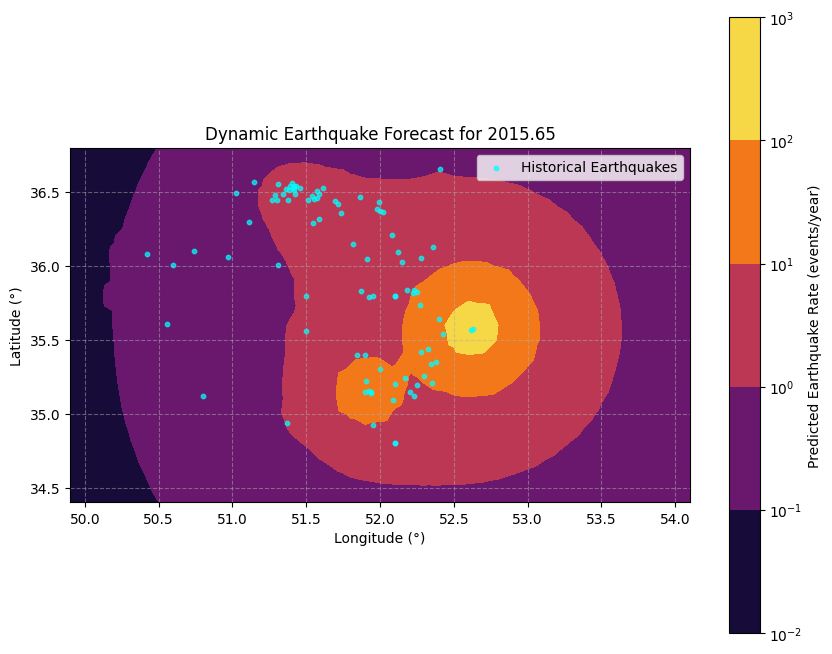


--- Phase 2 Complete ---


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from etas_model_functions import productivity, temporal_decay, spatial_distribution


def run_dynamic_forecast(grid_filepath, catalog_filepath, output_filepath):
    """
    Calculates and visualizes a dynamic earthquake forecast for a specific time.

    This function integrates the static susceptibility map (background rate) with
    the ETAS model to compute the total earthquake rate across the study grid.
    It calculates the rate at a specific forecast time, saves the results, and
    generates a map of the dynamic forecast.

    Args:
        grid_filepath (str): Path to the susceptibility map results from Phase 1.
        catalog_filepath (str): Path to the ETAS-ready earthquake catalog.
        output_filepath (str): Path to save the final dynamic forecast data.
    """
    print("--- Starting Phase 2, Step 3: Calculating the Dynamic Forecast ---")

    # --- 1. Define ETAS Model Parameters ---
    # These are example parameters based on typical values found in seismology literature.
    # A full scientific study would involve optimizing these for the specific region.
    ETAS_PARAMS = {
        "M0": 4.0,  # Minimum magnitude to trigger aftershocks
        "alpha": 2.3,  # Productivity scaling
        "c": 0.01,  # Omori's law time offset (years)
        "p": 1.1,  # Omori's law decay exponent
        "d": 0.01,  # Spatial scaling parameter
        "q": 1.5,  # Spatial decay exponent
    }
    print("Using example ETAS parameters:", ETAS_PARAMS)

    # --- 2. Load Data ---
    try:
        grid_df = pd.read_csv(grid_filepath)
        catalog = pd.read_csv(catalog_filepath)
        print(f"Loaded {len(grid_df)} grid points and {len(catalog)} catalog events.")
    except FileNotFoundError as e:
        print(f"Error: A required data file was not found. {e}")
        return

    # --- 3. Set Forecast Time ---
    # We'll calculate the forecast for one day after the last event in the catalog.
    forecast_time = catalog["time"].max() + (1 / 365.25)
    print(f"Calculating forecast for time: {forecast_time:.4f} decimal years.")

    # --- 4. Calculate the Total Earthquake Rate ---
    # The final rate is the sum of the background rate and the triggered rate.

    # Start with the background rate from our Phase 1 susceptibility map.
    # We need to scale it to represent an actual rate (events/year).
    # This scaling factor is a free parameter, we'll choose a small value.
    background_rate_scaling = 0.1
    total_rate = grid_df["susceptibility"].values * background_rate_scaling

    print("\nCalculating triggered rate from past earthquakes...")
    # Loop through every earthquake in the catalog that happened before our forecast time
    for index, event in catalog[catalog["time"] < forecast_time].iterrows():
        # A. Calculate productivity for this event
        K = productivity(event["magnitude"], ETAS_PARAMS["M0"], ETAS_PARAMS["alpha"])

        # B. Calculate temporal decay
        delta_t = forecast_time - event["time"]
        time_term = temporal_decay(delta_t, ETAS_PARAMS["c"], ETAS_PARAMS["p"])

        # C. Calculate spatial distribution
        delta_x = grid_df["longitude"].values - event["longitude"]
        delta_y = grid_df["latitude"].values - event["latitude"]
        space_term = spatial_distribution(
            delta_x,
            delta_y,
            event["magnitude"],
            ETAS_PARAMS["M0"],
            ETAS_PARAMS["d"],
            ETAS_PARAMS["q"],
            ETAS_PARAMS["alpha"],
        )

        # Combine terms and add to the total rate
        triggered_rate_contribution = K * time_term * space_term
        total_rate += triggered_rate_contribution

    grid_df["dynamic_rate"] = total_rate
    print("...Calculation complete.")

    # --- 5. Save the Results ---
    grid_df.to_csv(output_filepath, index=False)
    print(f"\nSuccessfully saved dynamic forecast results to: {output_filepath}")

    # --- 6. Visualize the Dynamic Forecast ---
    print("\nGenerating visualization...")
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use a logarithmic color scale because rates can vary by orders of magnitude
    from matplotlib.colors import LogNorm

    contour = ax.tricontourf(
        grid_df["longitude"],
        grid_df["latitude"],
        grid_df["dynamic_rate"],
        levels=14,
        cmap="inferno",
        norm=LogNorm(),
    )

    cbar = fig.colorbar(contour)
    cbar.set_label("Predicted Earthquake Rate (events/year)")

    ax.scatter(
        catalog["longitude"],
        catalog["latitude"],
        s=10,
        c="cyan",
        alpha=0.7,
        label="Historical Earthquakes",
    )

    ax.set_title(f"Dynamic Earthquake Forecast for {forecast_time:.2f}")
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_aspect("equal", adjustable="box")

    plt.show()
    print("\n--- Phase 2 Complete ---")


# --- Main execution block ---
if __name__ == "__main__":
    grid_file = "susceptibility_map_results.csv"
    catalog_file = "etas_catalog.csv"
    output_file = "dynamic_forecast_results.csv"

    run_dynamic_forecast(grid_file, catalog_file, output_file)
